## **Preparación del entorno**

In [ ]:
# Clonamos el repositorio (traemos las carpetas arms, algorithms, plotting...)
!git clone https://github.com/AngelD222/CasalsFranco.git

Cloning into 'CasalsFranco'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (213/213), done.
remote: Compressing objects: 100% (182/182), done.
remote: Total 478 (delta 39), reused 1 (delta 1), pack-reused 265 (from 1)
Receiving objects: 100% (478/478), 118.30 KiB | 4.93 MiB/s, done.
Resolving deltas: 100% (136/136), done.


In [ ]:
# Importamos todas las clases y funciones

import sys
import os
import numpy as np
from typing import List



repo_name = 'CasalsFranco/k_brazos/src'

# Añadimos la ruta al sistema
if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

print("Archivos en el directorio:")
!ls /content/{repo_name}

from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax, EpsilonDecay, UCB2
from arms import Bandit, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_mse

seed=2908
np.random.seed(seed)

Archivos en el directorio:
algorithms  arms  plotting


## **1. Experimento Bandido**

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado. Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Dado un bandido de k-brazos, se ejecutan 3 algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [ ]:
# RUN_EXPERIMENT CON MSE
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm_index = bandit.optimal_arm # Necesario para calcular el porcentaje de selecciones óptimas.
    optimal_expected_value = bandit.expected_rewards[optimal_arm_index]

    # Obtenemos los valores teóricos reales de todos los brazos
    true_rewards = np.array(bandit.expected_rewards)
    # Matrices para evolución temporal (Gráficas 1, 2 y 3)
    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.
    optimal_selections = np.zeros((len(algorithms), steps)) # Matriz para almacenar el porcentaje de selecciones óptimas
    regrets = np.zeros((len(algorithms), steps)) # Regret instantáneo

    # Error Cuadrático Medio de las estimaciones
    mses = np.zeros((len(algorithms), steps))

      # Acumuladores para estadísticas finales por brazo
    #   Necesitamos guardar para cada algoritmo:
    #   1. Cuántas veces eligió cada brazo (suma total)
    #   2. Cuánta recompensa sacó de cada brazo (suma total para hacer promedio)
    k = bandit.k
    total_arm_counts = np.zeros((len(algorithms), k))
    total_arm_rewards = np.zeros((len(algorithms), k))

    np.random.seed(seed)

    for run in range(runs):
        for algo in algorithms:
            algo.reset()
        # Nota: Si usamos counts internos del algoritmo se resetean en cada run.
        # Por eso necesitamos 'total_arm_counts' externo.
        current_bandit = bandit

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                # --- Recogida de datos ---
                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                if chosen_arm == optimal_arm_index:
                    optimal_selections[idx, step] += 1
                # Regret: Diferencia de valores esperados
                chosen_arm_expected = current_bandit.expected_rewards[chosen_arm]
                regrets[idx, step] += (optimal_expected_value - chosen_arm_expected)

                # Cálculo del MSE en este paso
                # Distancia al cuadrado entre lo que el agente cree (algo.values) y la realidad (true_rewards)
                mse_step = np.mean((algo.values - true_rewards) ** 2)
                mses[idx, step] += mse_step
                # Recogida de datos globales por brazo
                total_arm_counts[idx, chosen_arm] += 1
                total_arm_rewards[idx, chosen_arm] += reward

    # Procesamiento final

    # 1. Promedios temporales
    rewards /= runs
    optimal_selections /= runs
    regrets /= runs
    mses /= runs # Promedio del MSE

    # Calculamos el Regret acumulado (suma acumulativa del regret promedio instantáneo)
    cumulative_regrets = np.cumsum(regrets, axis=1)

    # 2. Estructura para plot_arm_statistics
    arm_stats = []
    for idx in range(len(algorithms)):
        # Evitar división por cero si un brazo nunca se eligió
        with np.errstate(divide='ignore', invalid='ignore'):
            avg_rewards_per_arm = total_arm_rewards[idx] / total_arm_counts[idx]
            avg_rewards_per_arm = np.nan_to_num(avg_rewards_per_arm)

        # Normalizamos los conteos para que sea "promedio de selecciones por run"
        # Usaremos promedio por run para que los números no sean gigantes
        avg_counts_per_arm = total_arm_counts[idx] / runs

        stats = {
            'counts': avg_counts_per_arm,
            'rewards': avg_rewards_per_arm,
            'optimal_index': optimal_arm_index
        }
        arm_stats.append(stats)

    # Ahora devolvemos 5 cosas (incluyendo mses)
    return rewards, optimal_selections, cumulative_regrets, mses, arm_stats

### **1.1. Ejecución del experimento algoritmo greedy con $\epsilon=0$, $\epsilon=0.01$, $\epsilon=0.1$**

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución de Bernoulli. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [ ]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k=k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento
rewards, optimal_selections, cumulative_regrets, mses, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBernoulli(p=0.61), ArmBernoulli(p=0.71), ArmBernoulli(p=0.22), ArmBernoulli(p=0.32), ArmBernoulli(p=0.16), ArmBernoulli(p=0.44), ArmBernoulli(p=0.81), ArmBernoulli(p=0.55), ArmBernoulli(p=0.40), ArmBernoulli(p=0.88)
Optimal arm: 10 with expected reward=0.8816


### **1.2. Visualización de los resultados**

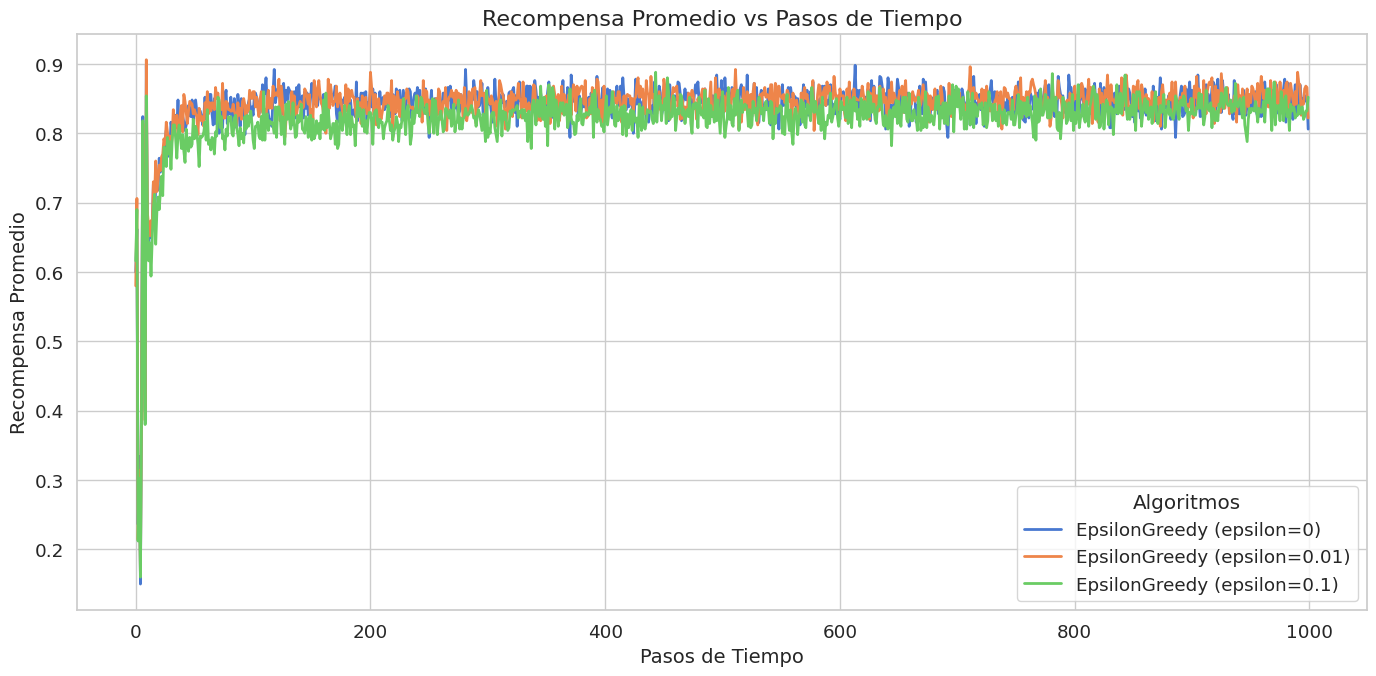

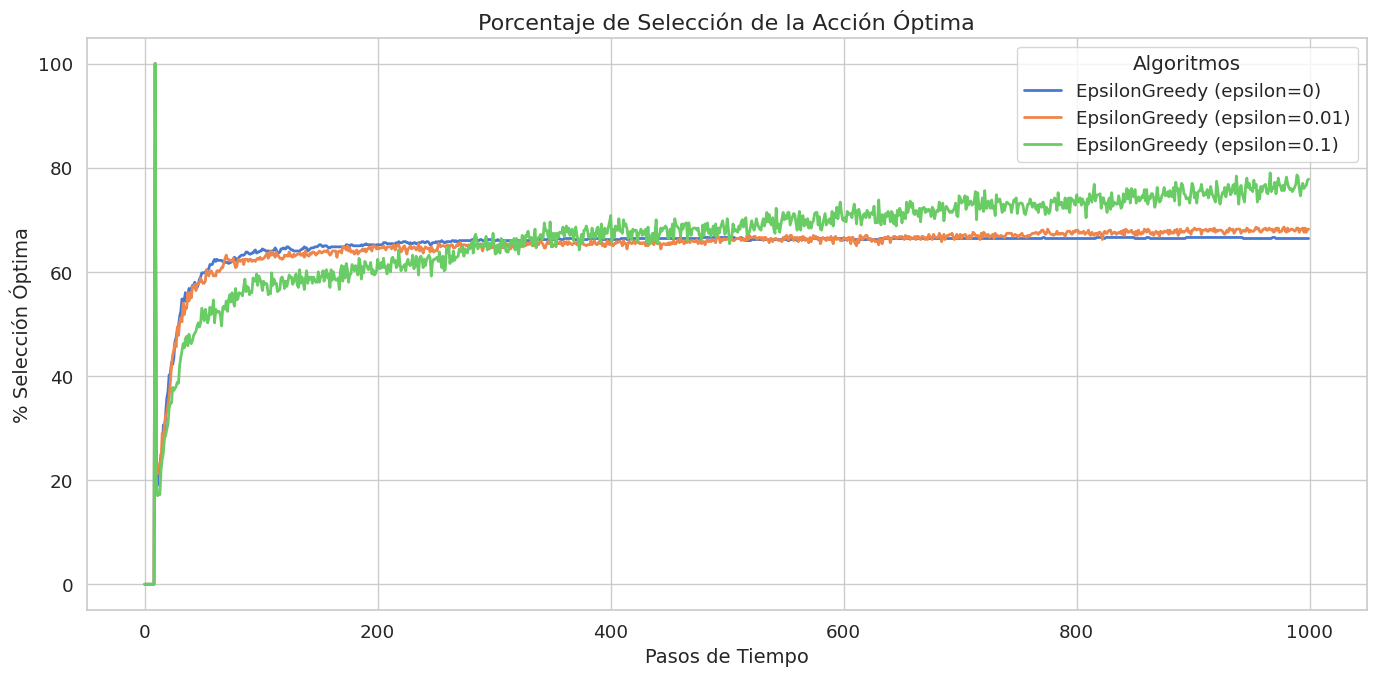

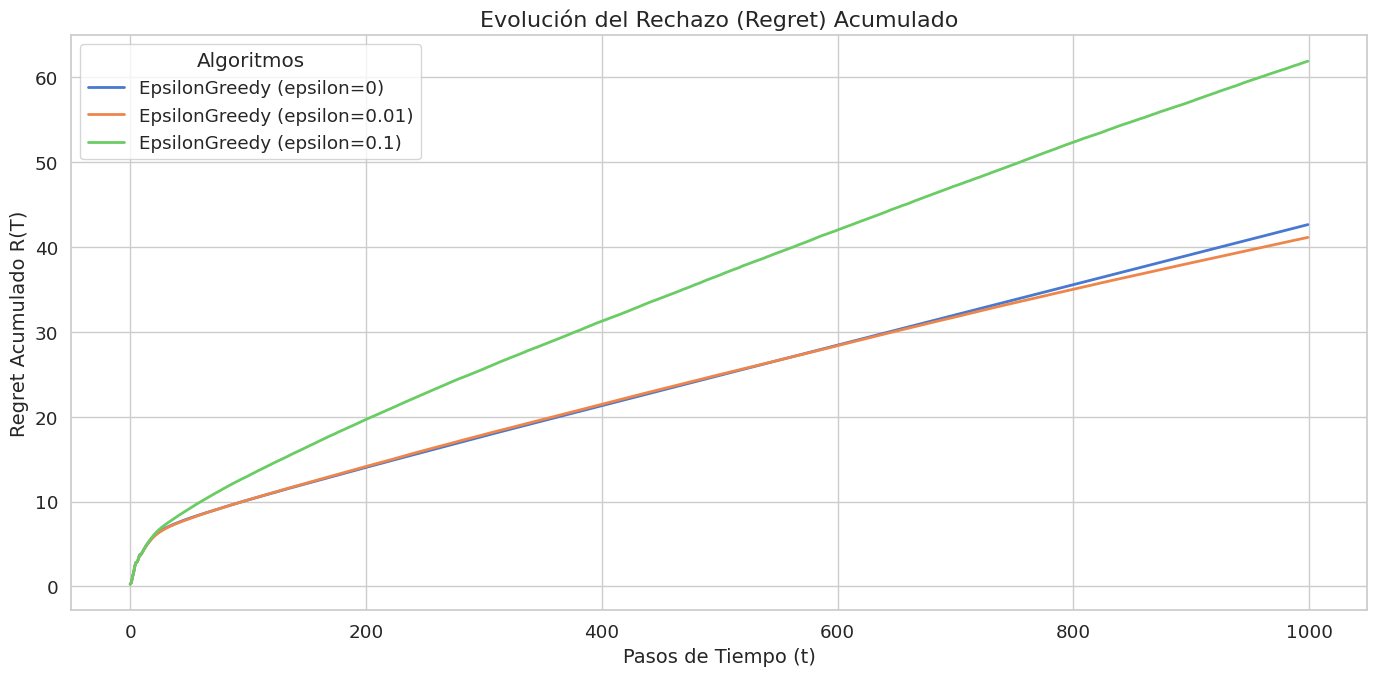

Generando estadísticas detalladas por brazo...


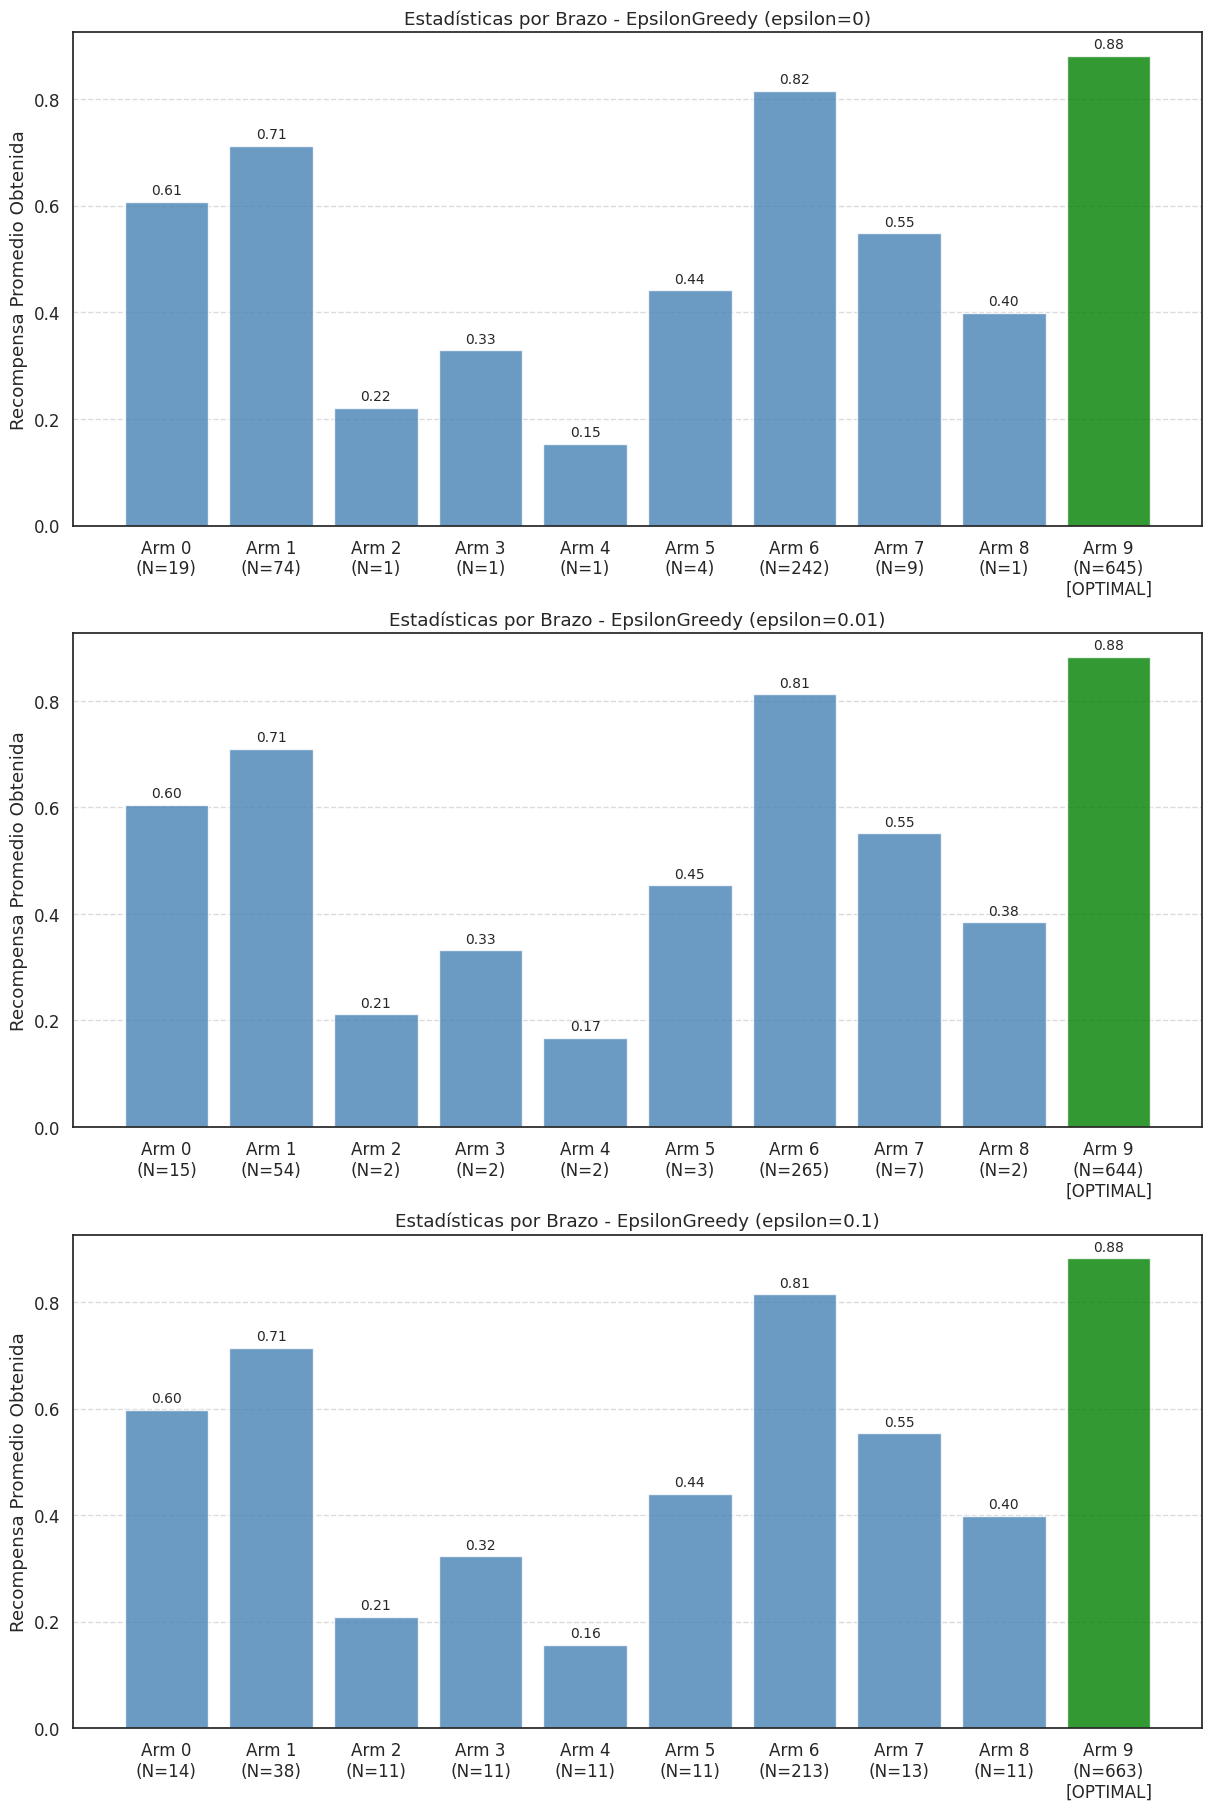

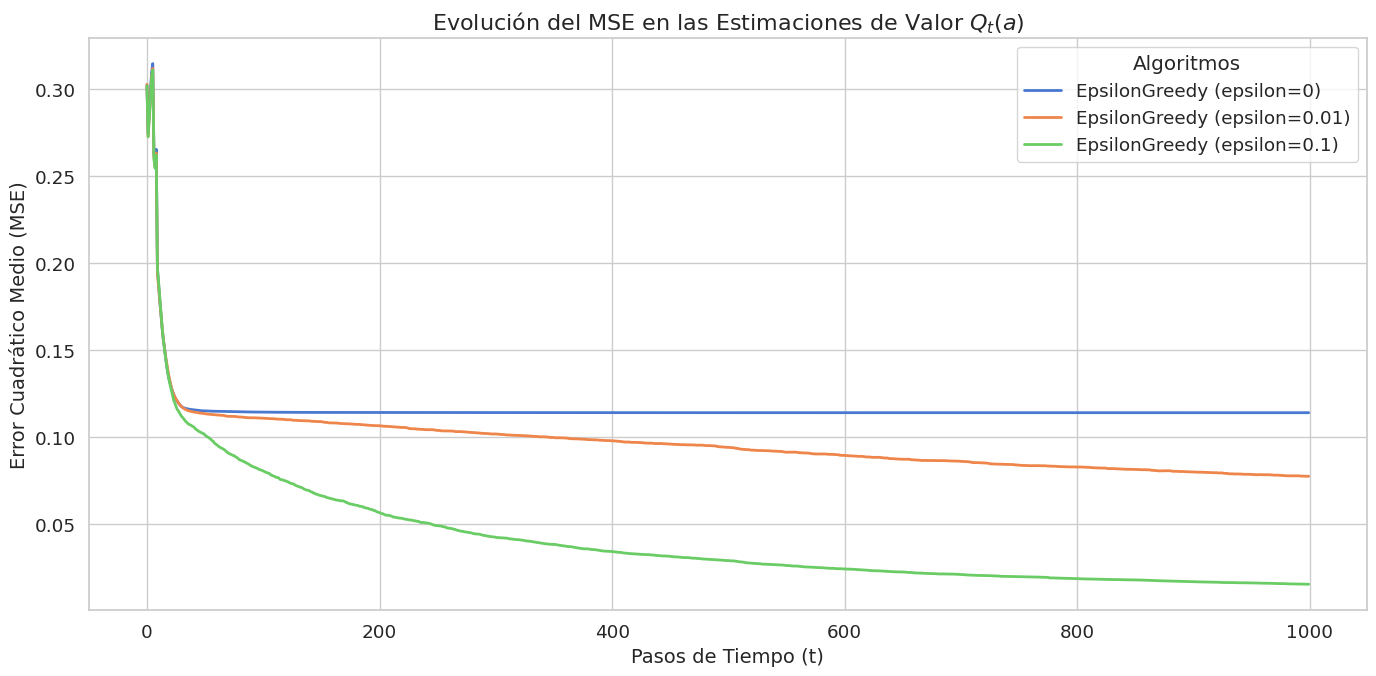

In [ ]:
# 1. Recompensa Promedio
plot_average_rewards(steps, rewards, algorithms)

# 2. % Selección Óptima
plot_optimal_selections(steps, optimal_selections, algorithms)

# 3. Regret Acumulado
plot_regret(steps, cumulative_regrets, algorithms)

# 4. Estadísticas detalladas por brazo
print("Generando estadísticas detalladas por brazo...")
plot_arm_statistics(arm_stats, algorithms)

# 5. Error Cuadrático Medio (MSE)
plot_mse(steps, mses, algorithms)

### **Análisis detallado de la imagen**

1. **Recompensa promedio vs pasos de tiempo**
Este gráfico muestra cómo evoluciona la recompensa promedio a lo largo del tiempo.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: recompensa promedio acumulada*

En cuanto a los resultados, es difícil distinguir las tres variaciones del algoritmo que disponemos pues para todos los epsilons las recompensas son muy similares

2. **Porcentaje de selección de la acción óptima**

Este gráfico representa qué tan frecuente es que cada algoritmo seleccione el mejor brazo.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: % de veces que se elige la acción óptima*

Aquí sí podemos ver un primer pico para epsilon=0.1 y que posteriormente es el algoritmo que más es capaz de explorar y mejorar su selección con el tiempo.
Aunque más lento, el valor 0.01 también es capaz de evolucionar con el tiempo, mientras que para epsilon=0, el comportamiento es claro, se estancaa en la explotación de una acción que no es la óptima

3. **Evolución del regret acumulado**

El regret mide cuánto se pierde por no elegir siempre la mejor acción.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: regret acumulado*

Igual que elige la acción óptima antes que cualquiera, epsilon=0.1 también es el ganador en cuanto al regret acumulado, es decir tiene que pagar un precio por alcanzar esa acción óptima. quedando los otros dos valores bastante alejados por debajo de este, y siendo el epsilon=0.01 el de regret más bajo.

4. **Estadísticas por brazo**

Para este tipo de gráfica tenemos una por cada algoritmo. En cada gráfico:

- *El Eje x representa los distintos brazos disponibles (Arm 0 a Arm 9).*

- *El Eje y indica la recompensa promedio obtenida al seleccionar cada brazo.*

La barra verde señala el brazo identificado como óptimo.


En todos los algoritmos, el brazo resaltado en verde corresponde al que ofrece la mayor recompensa promedio. Esto indica que el entorno tiene un brazo claramente superior, y el objetivo es descubrirlo lo antes posible, y la diferencia clave entre algoritmos será precisamente cuán rápido lo descubren.

Debajo de cada barra aparece el número de veces que cada brazo fue elegido (N=...). Los algoritmos más eficientes asignan muchas más selecciones al brazo óptimo, reduciendo exploraciones innecesarias. Aquí vemos que se parecen mucho los resultados en tanto en cuanto los tres valores hacen una pequeña exploración por todos los brazos y claramente son capaces de enfocarse rápidamente en el brazo ganador. La clave es cuánto han sido capaces de elegir el brazo ótpimo, siendo 0.1 el que más, seguido de 0.01 y por último 0

#### **Experimento $\epsilon$-greedy (Normal vs. Bernoulli)**



Mientras que bajo la distribución Normal las curvas de recompensa promedio son más suaves y muestran una separación rápida y clara del rendimiento según el valor de $\epsilon$, con la distribución de Bernoulli hay un desafío más grande debido a la naturaleza binaria de la recompensa. Esto se traduce en una convergencia más lenta, requiriendo más interacción con el entorno para que las estimaciones $Q_t(a)$ se estabilicen y el algoritmo pueda distinguir el brazo óptimo.

### ***NOTA:***
Explotación (ε=0): Hemos modificado el código inicial en el método `select_arm` en `algorithms/epsilon_greedy.py` dado por el profesor ya que, anteriormente, siempre eligía la mejor opción conocida, y si inicialmente se selecciona un brazo subóptimo, nunca descubre otras opciones más rentables.

Con este nuevo método:

- Inicialización: Se fuerza la exploración de acciones no visitadas (counts[i] == 0) para garantizar que las estimaciones de $Q(a)$ no estén sesgadas por la falta de datos iniciales.

- Rotura de empates: El np.argmax estándar es determinista (siempre elige el primero). Al usar np.random.choice(best_arms), eliminamos el sesgo posicional en caso de que varios brazos tengan la misma recompensa esperada actual.

## **2. Estudio comparativo entre algoritmos $\epsilon$-greedy, $\epsilon$-decaimiento, UCB1, UCB2 y Softmax con bandido siguiendo distribución Bernoulli**

In [ ]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandido
bandit = Bandit(arms=ArmBernoulli.generate_arms(k=k))
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar:
algorithms = [
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),
    Softmax(k=k, tau=0.1),
    EpsilonDecay(k=k, epsilon=0.1, decay=0.001),
    UCB2(k=k, alpha=0.5)
]

# Ejecutar el experimento
rewards, optimal_selections, cumulative_regrets, mses, arm_stats = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.78), ArmBernoulli(p=0.37), ArmBernoulli(p=0.68), ArmBernoulli(p=0.35), ArmBernoulli(p=0.80), ArmBernoulli(p=0.39), ArmBernoulli(p=0.31), ArmBernoulli(p=0.55), ArmBernoulli(p=0.39), ArmBernoulli(p=0.68)
Optimal arm: 5 with expected reward=0.8006


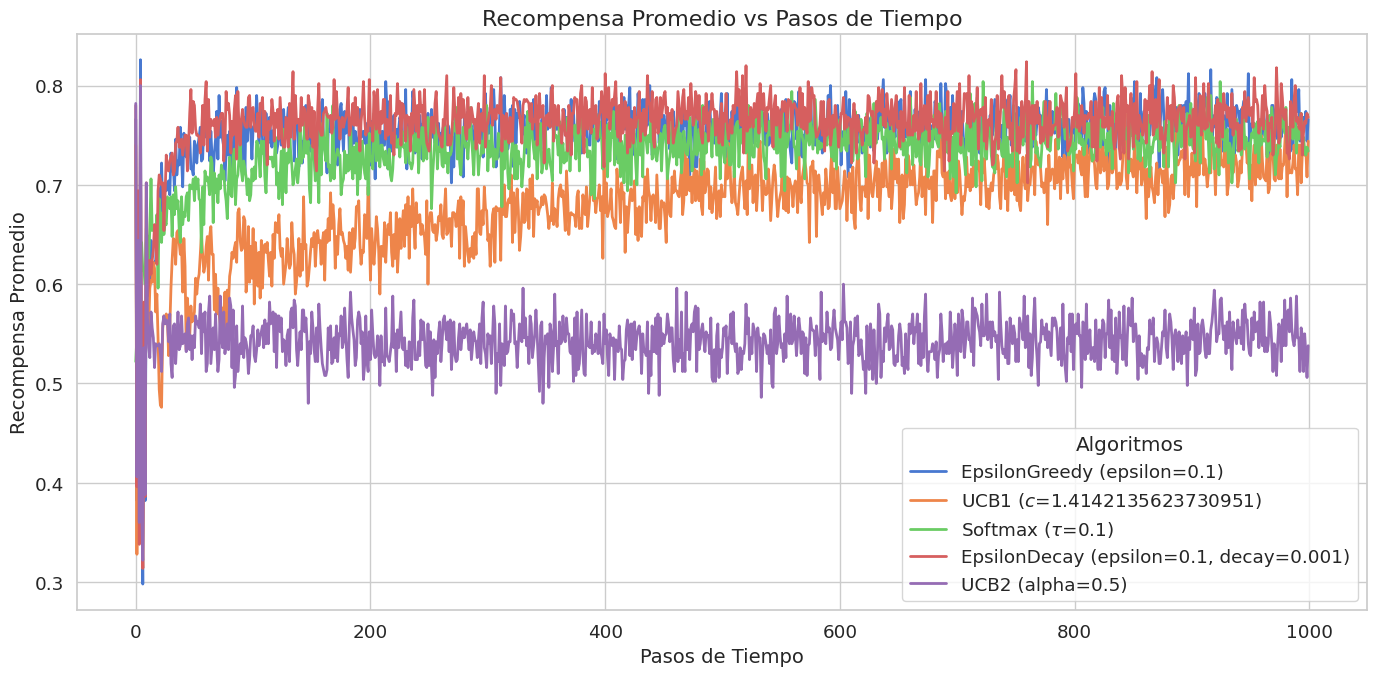

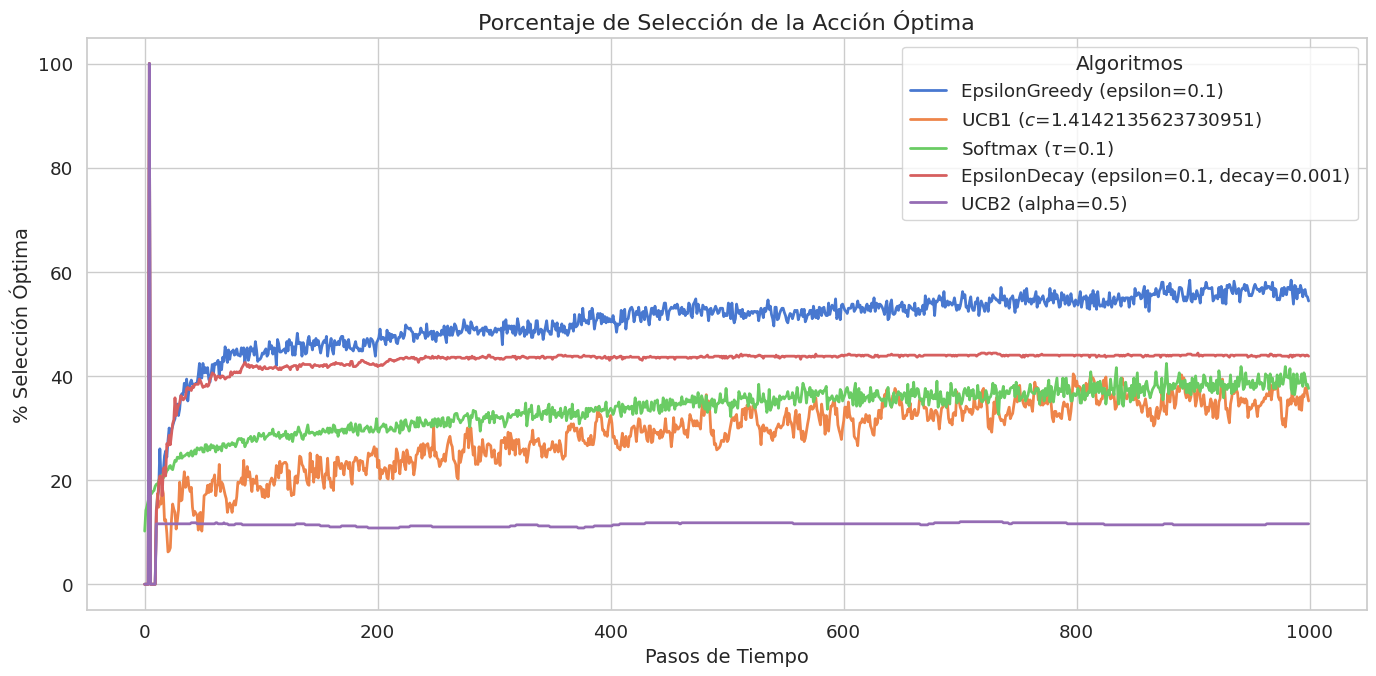

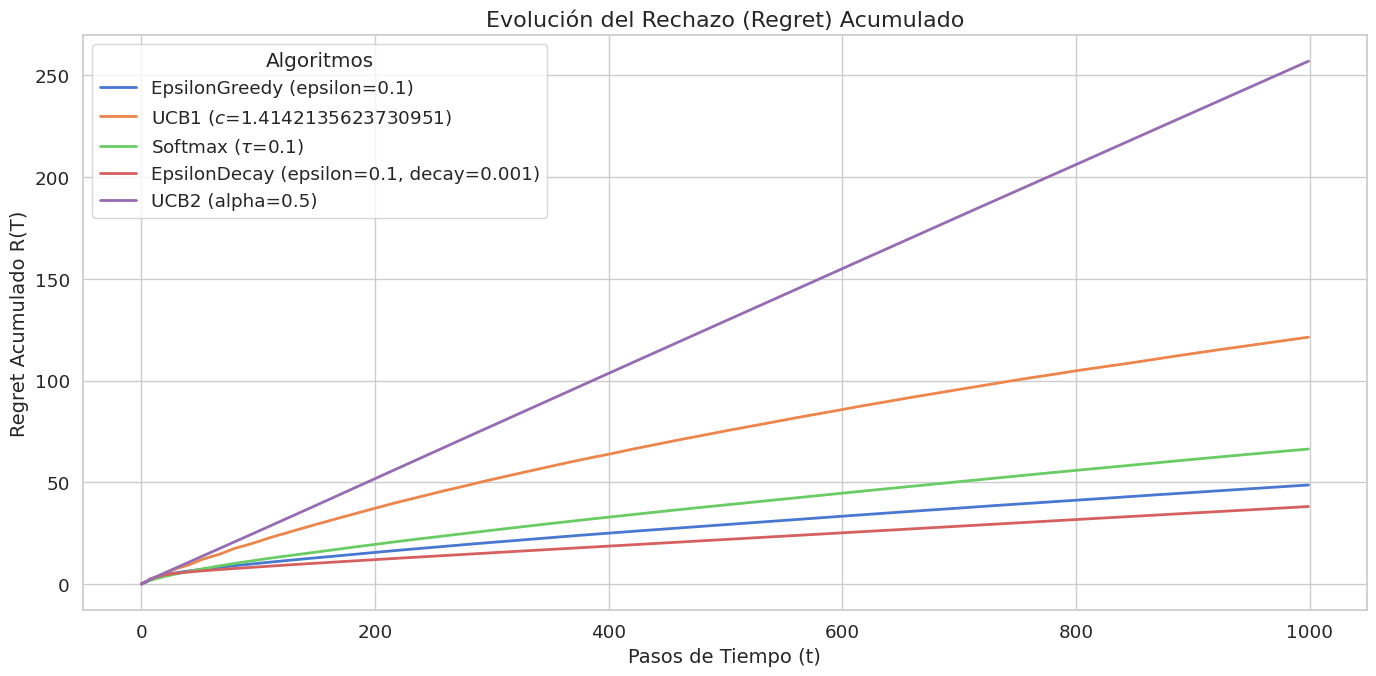

Generando estadísticas detalladas por brazo...


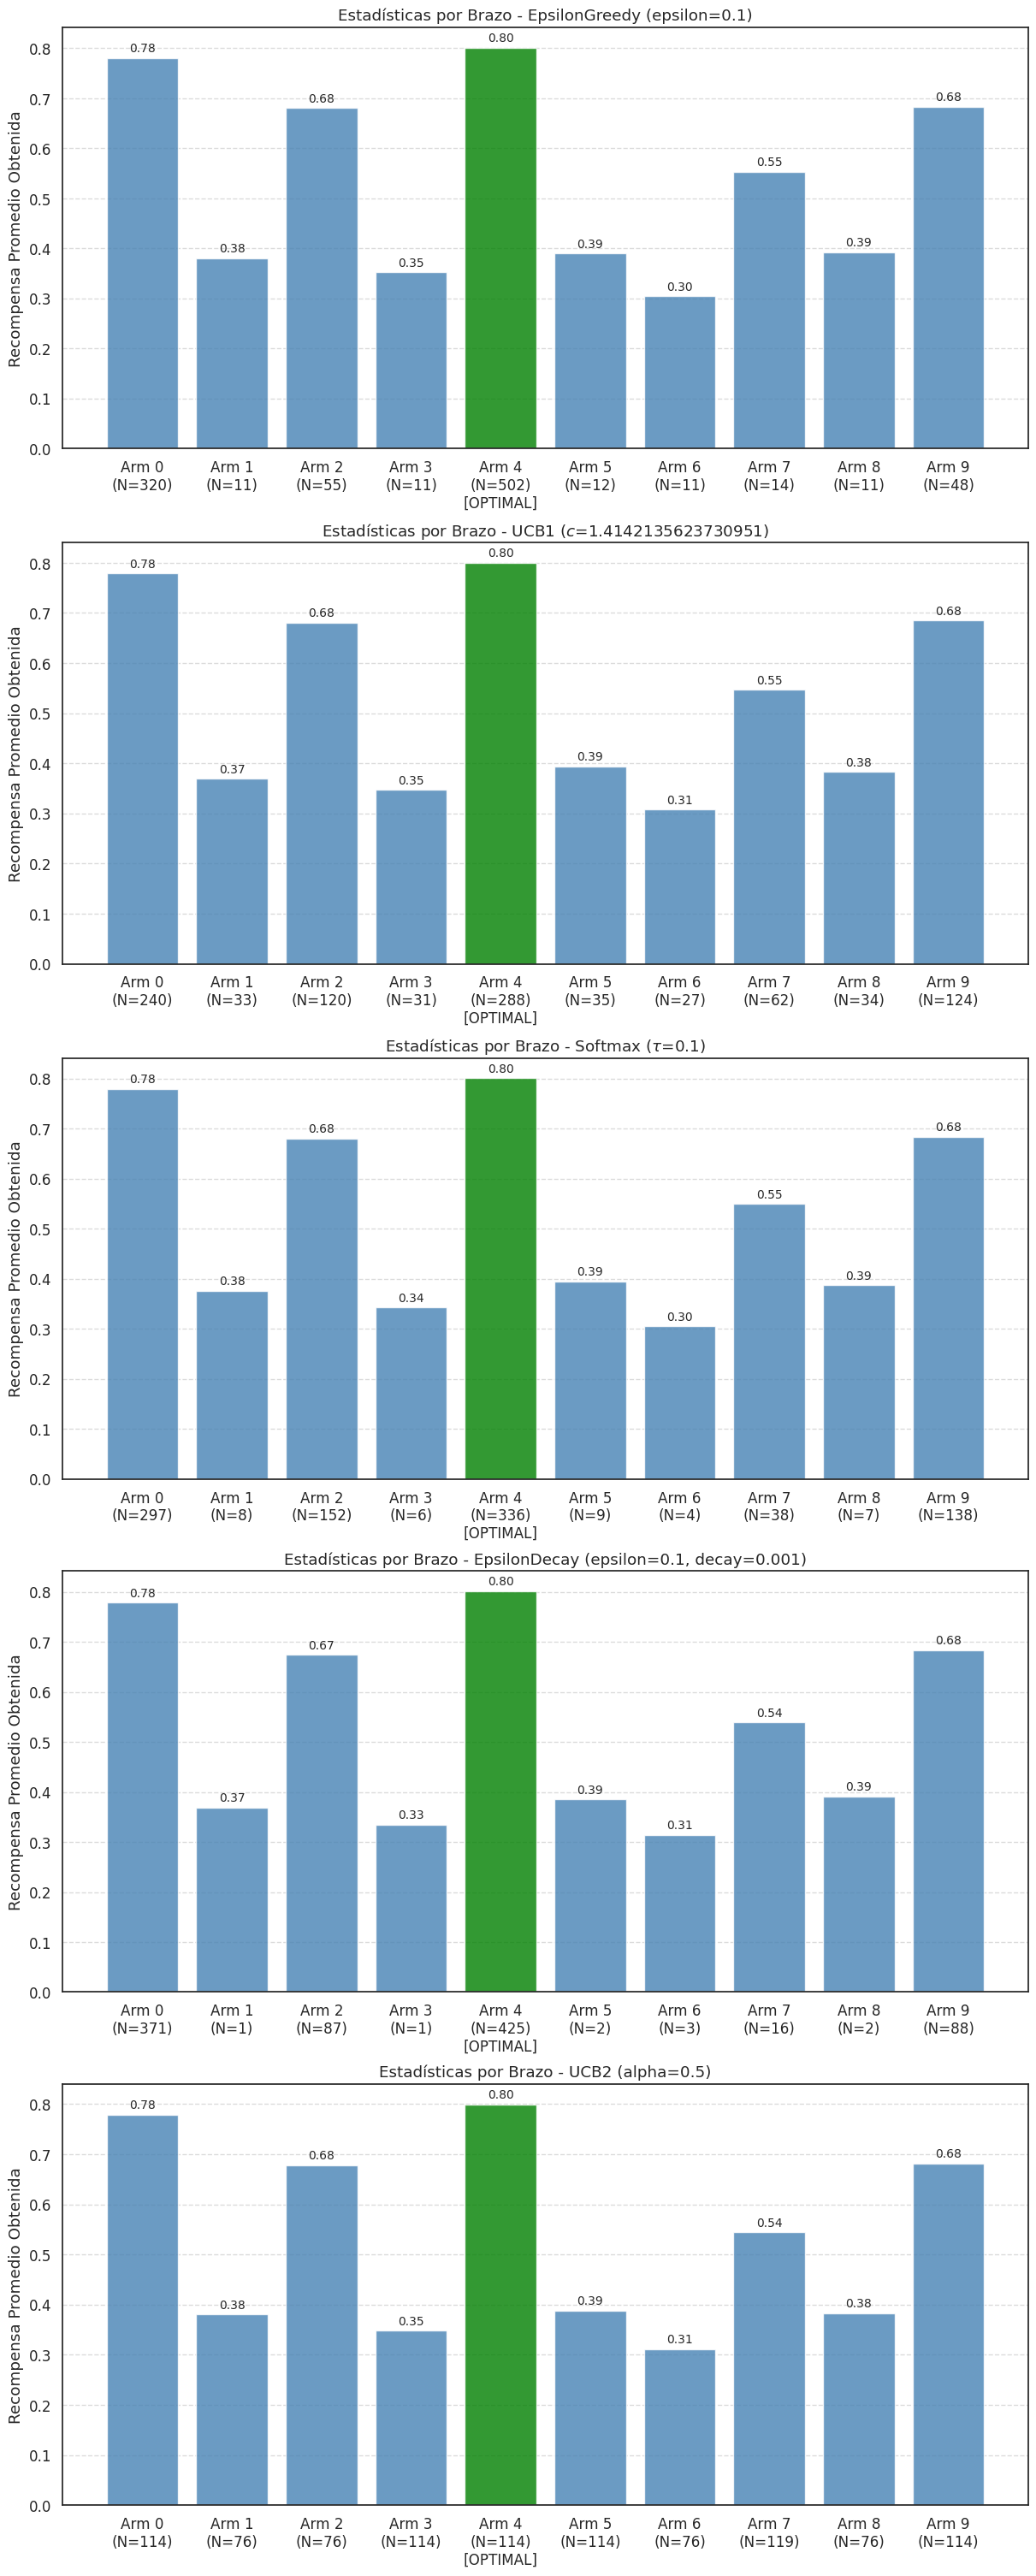

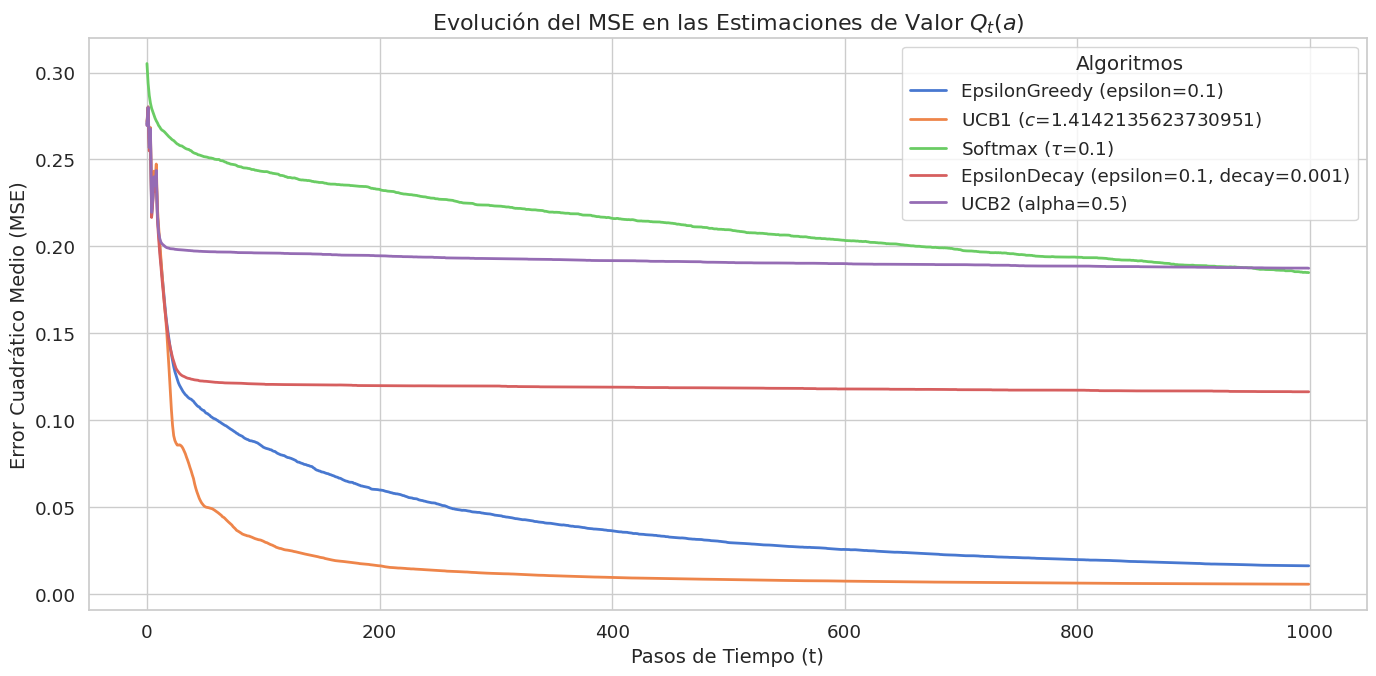

In [ ]:
# 1. Recompensa Promedio
plot_average_rewards(steps, rewards, algorithms)

# 2. % Selección Óptima
plot_optimal_selections(steps, optimal_selections, algorithms)

# 3. Regret Acumulado
plot_regret(steps, cumulative_regrets, algorithms)

# 4. Estadísticas detalladas por brazo
print("Generando estadísticas detalladas por brazo...")
plot_arm_statistics(arm_stats, algorithms)

# 5. Error Cuadrático Medio (MSE)
plot_mse(steps, mses, algorithms)

### **Análisis detallado de la imagen**

1. **Recompensa promedio vs pasos de tiempo**
Este gráfico muestra cómo evoluciona la recompensa promedio a lo largo del tiempo.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: recompensa promedio acumulada*

En cuanto a los resultados, bajo esta distribución los resultados no son tan extremos. Ya no son UCB los que despuntan sino Epsilon-Decay y Epsilon-Greedy los que están al alza. Softmax pasa a dar un resultado razonablemente bueno y quedan como peores algoritmos UCB1 y UCB2, que aunque alcanzan una primera recomensa altísima en un primer momento, siguen con la exploración y no son capaces de encontrar el brazo ótpimo dada la distribución binaria.

2. **Porcentaje de selección de la acción óptima**

Este gráfico representa qué tan frecuente es que cada algoritmo seleccione el mejor brazo.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: % de veces que se elige la acción óptima*

Como veíamos en el gráfico anterior, UCB2 es en una primera exploración dar con el brazo óptimo, pero debido a la distribución binaria no es capaz de distinguirlo y continua con la exploración obteniendo así el peor resultado.
Epsilon-Greedy es el mejor algoritmo, pues con tiempo suficiente es el que alcanza de forma estable la acción óptima dentro de todos los algoritmos, aunque se queda entorno a un 60%. Le siguen Epsilon-Decay, con un intención no tan creciente, probablemente Softmax y tal vez UCB1 que son los algoritmos que le siguen en ese orden, dada su intención creciente con el tiempo, con tiempo suficiente pudieran superarle.

3. **Evolución del regret acumulado**

El regret mide cuánto se pierde por no elegir siempre la mejor acción.

- *Eje x: pasos de tiempo (iteraciones)*

- *Eje y: regret acumulado*

Aquí por encima de todos tenemos a UCB2 con el regret más grande y creciente. Le siguen UCB1 y softax y cierran la gráfica los algoritmos Epsilon.

4. **Estadísticas por brazo**

Para este tipo de gráfica tenemos una por cada algoritmo. En cada gráfico:

- *El Eje x representa los distintos brazos disponibles (Arm 0 a Arm 9).*

- *El Eje y indica la recompensa promedio obtenida al seleccionar cada brazo.*

La barra verde señala el brazo identificado como óptimo.


En todos los algoritmos, el brazo resaltado en verde corresponde al que ofrece la mayor recompensa promedio. Esto indica que el entorno tiene un brazo claramente superior, y el objetivo es descubrirlo lo antes posible, y la diferencia clave entre algoritmos será precisamente cuán rápido lo descubren.

Debajo de cada barra aparece el número de veces que cada brazo fue elegido (N=...). Los algoritmos más eficientes asignan muchas más selecciones al brazo óptimo, reduciendo exploraciones innecesarias.
Estas gráficas representan todo lo comentado, a pesar de que UCB1 y UCB2 son los más rápidos en encontrar el brazo óptimo, continuan con su exploración y tienen una cantidad de elecciones por brazos muy parecida. Por contraparte, los algoritmos Epsilons son los que tras poca exploración en el resto de brazos, son capaces de elegir el óptimo y asentarse en él sin problema, seguido de un algoritmo Softmax, que aunque requiere de algo más de exploración, también es capaz de centrarse en ese brazo con el tiempo.